**ResNet50-based CNN architecture on Reshuffled All-Model Balanced Samples**

In this Notebook we implement a transfer learning approach using a ResNet50-based architecture, that learns features and classifies images as either AI or Real. 
The approach focuses on fine-tuning, balanced datasets, and data augmentation to get improved results.

In [120]:
# The lines below can be un-commennted to install sciki-learn and seaborn.
# !pip install scikit-learn
# !pip install seaborn

In [121]:
import os
import time
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet50_Weights
from sklearn.metrics import classification_report
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset


**Step 1 – Configure device and project paths**

The device is selected by checking the avalibility between a CUDA, CPU or MPS
Further, project directory paths and output directories and checkpoints are also defined.

In [122]:
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [123]:
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError: 
    PROJECT_ROOT = Path.cwd().parent
    OUTPUT_ROOT = PROJECT_ROOT / "output"

In [124]:
OUTPUT_ROOT = PROJECT_ROOT / "output"
TRAIN_PATH  = str(OUTPUT_ROOT / "train_balanced")
VAL_PATH    = str(OUTPUT_ROOT / "validation_balanced")
TEST_PATH   = str(OUTPUT_ROOT / "test_balanced")

In [125]:
try: 
    CHECKPOINT_PATH = str(Path(__file__).resolve().parent / "genai_resnet50_v2_best.pth")
except NameError:
    CHECKPOINT_PATH = str(Path.cwd() / "genai_resnet50_v2_best.pth")

**Step 2 – Define hyperparameters**

Hyperparameters are defined including:

Image size for sizing

Batch size

Epochs

Learning Rates

Early stopping

In [126]:
IMAGE_SIZE    = 224
BATCH_SIZE    = 16
NUM_WORKERS   = 0
WARM_UP_EPOCHS = 3       
N_EPOCHS      = 10       
PATIENCE      = 5        
HEAD_LR       = 1e-3     
BACKBONE_LR   = 1e-5     
WEIGHT_DECAY  = 1e-4

**Step 3 – Apply data transformations and augmentation**

Data tranformations are applied seperately for Training and Val_Test sets
Training augmentations include flipping, and transformations to improve generalization. Val_Test are only resized and normalized.

In [127]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(degrees=15),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [128]:
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

**Step 4 – Dataset reshuffling**

3 different datasets are made for Training, Validation and Testing.
A reshuffling approach is applied here to achieve better results.
All of the balanced data from the 3 sets is combined into a larger pool and then seperate sets are created here. The reason for this is that the pre-split train and test data was fundamentally different, and would give significantly worse results.

The dataset can be found at 'https://huggingface.co/datasets/Rajarshi-Roy-research/Defactify_Image_Dataset'

To run this, you may need to modify the directories and the manifenst files. See attached script for downloading data with corresponding manifests.

In [129]:
class MixedImageDataset(Dataset): 
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.classes = ['ai_generated', 'real']

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = str(self.file_paths[idx])
        img = Image.open(path).convert("RGB")

        label = 0 if "ai_generated" in path else 1
        if self.transform:
            img = self.transform(img)
        return img, label

balanced_dirs = [Path(TRAIN_PATH), Path(VAL_PATH), Path(TEST_PATH)]

all_ai_paths = [p for d in balanced_dirs for p in (d / "ai_generated").iterdir() if p.is_file()]
all_real_paths = [p for d in balanced_dirs for p in (d / "real").iterdir() if p.is_file()]


all_paths = all_ai_paths + all_real_paths
all_labels = [0]*len(all_ai_paths) + [1]*len(all_real_paths)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, train_size=0.70, stratify=all_labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, train_size=0.50, stratify=temp_labels, random_state=42
)

train_dataset = MixedImageDataset(train_paths, transform=train_transform)
val_dataset = MixedImageDataset(val_paths, transform=val_test_transform)
test_dataset = MixedImageDataset(test_paths, transform=val_test_transform)

print(f"SHUFFLED DATASETS -- TRAIN: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

SHUFFLED DATASETS -- TRAIN: 18160 | Val: 3891 | Test: 3892


In [130]:
print(f"Classes : {train_dataset.classes}")
print(f"Train   : {len(train_dataset)}")
print(f"Val     : {len(val_dataset)}")
print(f"Test    : {len(test_dataset)}")

Classes : ['ai_generated', 'real']
Train   : 18160
Val     : 3891
Test    : 3892


In [131]:
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
testloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

**Step 5 – Define custom model with ResNet50 backbone**

A custom model class is defined here with a ResNet50 backbone.

We had experimented with both ResNet50 and ResNet but decided to proceed with ResNet50 due to better overall results.

Here the classifier head is replaced by a dropout-based classification head.
Setup for initially freezing the backbone is also defined here.

In [132]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()
        backbone = models.resnet50(weights=ResNet50_Weights.DEFAULT)

        in_features = backbone.fc.in_features  
        backbone.fc = nn.Sequential(
            nn.Dropout(p=0.4),                 
            nn.Linear(in_features, num_classes),
        )
        self.feature_extractor = backbone

        if freeze_backbone:
            for name, param in self.feature_extractor.named_parameters():
                if "fc" not in name:
                    param.requires_grad = False

    def forward(self, x):
        return self.feature_extractor(x)

In [133]:
num_classes = len(train_dataset.classes)
net = AiGenModel(num_classes=num_classes, freeze_backbone=True).to(device)

In [134]:
def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [135]:
print(f"\nPhase 1 – warm-up: trainable params = {count_trainable(net):,}")


Phase 1 – warm-up: trainable params = 4,098


**Step 6 – Progressive unfreezing strategy**

After initial warm-up epochs the deeper layers (3 and 4) of the backbone are unfrozen.
This is done to enable fine tuning of higher level features. 

In [136]:
def unfreeze_later_blocks(model):
    for name, param in model.feature_extractor.named_parameters():
        if "layer3" in name or "layer4" in name:
            param.requires_grad = True

**Step 7 – Define optimizer and learning rate strategy**

AdamW is used as the optimizer due to it's prior use for similar cases. 

Differentiatle learning rates are used for the classifier head (higher) and the backbone (lower) to avoid catastrophic forgetting.

In [137]:
def make_optimizer(model):
    head_params     = [p for n, p in model.feature_extractor.named_parameters()
                       if "fc" in n and p.requires_grad]
    backbone_params = [p for n, p in model.feature_extractor.named_parameters()
                       if "fc" not in n and p.requires_grad]
    groups = [{"params": head_params, "lr": HEAD_LR}]
    if backbone_params:
        groups.append({"params": backbone_params, "lr": BACKBONE_LR})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

In [138]:
criterion = nn.CrossEntropyLoss()
optimizer = make_optimizer(net)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

In [139]:
best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
fine_tune_started = False

**Step 8 – Train the model with warm-up and fine-tuning**

This is the main training loop that runs for a set number of epochs (10 here)
Key steps are the forward pass, loss computation, backpropogation and weight updates. 

Initialy only the classifier head is trained in later epochs the deeper layers are updated.

In [ ]:
for epoch in range(N_EPOCHS):
    if epoch == WARM_UP_EPOCHS and not fine_tune_started:
        print(f"\n{'='*60}")
        print(f"Warm-up done. Unfreezing layer3 + layer4 for fine-tuning.")
        unfreeze_later_blocks(net)
        optimizer = make_optimizer(net) 
        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
        fine_tune_started = True
        print(f"Phase 2 – fine-tune: trainable params = {count_trainable(net):,}")
        print(f"{'='*60}\n")

    epoch_start = time.perf_counter()
    net.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc  = correct / total

    net.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_dataset)
    val_acc  = correct / total

    scheduler.step(val_loss)
    epoch_time = time.perf_counter() - epoch_start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    phase = "WARM-UP " if epoch < WARM_UP_EPOCHS else "FINE-TUNE"
    print(f"[{phase}] Epoch {epoch+1:02d}/{N_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"{epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), CHECKPOINT_PATH)
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

[WARM-UP ] Epoch 01/10 | train_loss=0.5846 train_acc=0.6895 | val_loss=0.5268 val_acc=0.7489 | 443.8s
  ✓ Best model saved (val_loss=0.5268)
[WARM-UP ] Epoch 02/10 | train_loss=0.5630 train_acc=0.7130 | val_loss=0.5182 val_acc=0.7587 | 439.1s
  ✓ Best model saved (val_loss=0.5182)


In [ ]:
print("\nTraining complete.")


Training complete.


**Step 9 – Load best model for evaluation**

The best model checkpoint is loaded for testing.

In [ ]:
print(f"\nLoading best checkpoint from {CHECKPOINT_PATH} ...")
net.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
net.eval()


Loading best checkpoint from /Users/saadahmadmalik/Documents/UCal-Uni-Work/ML/Project/ENSF617-Project/prototype-notebooks/genai_resnet50_v2_best.pth ...


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [ ]:
class_names = train_dataset.classes
class_correct = [0] * num_classes
class_total   = [0] * num_classes
all_correct, all_total = 0, 0

In [ ]:
all_preds = []
all_targets = []

**Step 10 – Evaluate model on test dataset**

The best model is evaluated on the test set.

A classification report is made. 
Metrics shows are precision, recall and F1. 


In [ ]:
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)

        all_total   += labels.size(0)
        all_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

        for c in range(num_classes):
            mask = (labels == c)
            class_total[c]   += mask.sum().item()
            class_correct[c] += (predicted[mask] == labels[mask]).sum().item()

In [ ]:
print(f"\n{'='*50}")
print(f"TEST RESULTS")
print(f"{'='*50}")
print(f"Overall accuracy : {all_correct/all_total:.4f}  ({all_correct}/{all_total})")
print()
for c in range(num_classes):
    acc = class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0
    print(f"  {class_names[c]:15s} : {acc:.4f}  ({class_correct[c]}/{class_total[c]})")


TEST RESULTS
Overall accuracy : 0.8535  (3322/3892)

  ai_generated    : 0.8660  (1292/1492)
  real            : 0.8458  (2030/2400)


In [ ]:
print(f"\n{'-'*50}")
print(f"CLASSIFICATION REPORT (Precision, Recall, F1-Score)")
print(f"{'-'*50}")
report = classification_report(all_targets, all_preds, target_names=class_names, digits=4)
print(report)
print(f"{'='*50}")


--------------------------------------------------
CLASSIFICATION REPORT (Precision, Recall, F1-Score)
--------------------------------------------------
              precision    recall  f1-score   support

ai_generated     0.7774    0.8660    0.8193      1492
        real     0.9103    0.8458    0.8769      2400

    accuracy                         0.8535      3892
   macro avg     0.8438    0.8559    0.8481      3892
weighted avg     0.8594    0.8535    0.8548      3892


Baseline (frozen backbone, 1 epoch): overall=0.5300, ai_generated=0.7453, real=0.3949


**Step 11 – Post-analysis with metadata**

Here we get the final analysis with a confusion matrix and the per-AI model class results for a deeper understanding of the results.

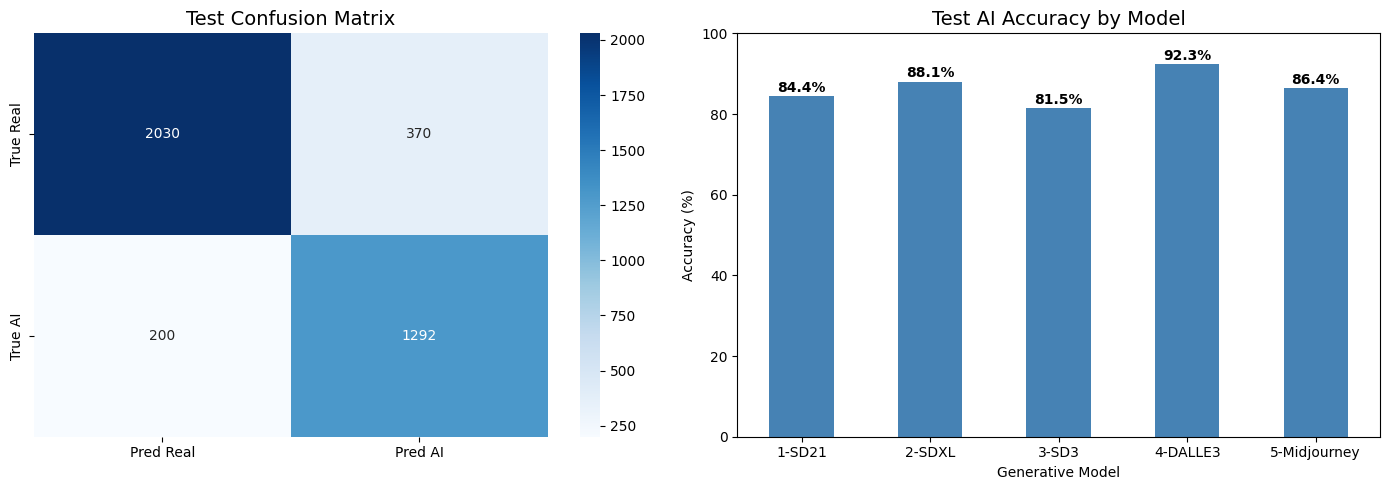

In [ ]:
all_csvs = pd.concat([pd.read_csv(p) for p in Path(OUTPUT_ROOT, "metadata").glob("*_balanced_manifest.csv")])
all_csvs['filename'] = all_csvs['image_path'].apply(lambda path: Path(path).name)

test_results = pd.DataFrame({
    'filename': [Path(p).name for p in test_dataset.file_paths],
    'target': all_targets,
    'prediction': all_preds
})

merged = test_results.merge(all_csvs[['filename', 'label_b']], on='filename')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(merged['target'], merged['prediction'], labels=[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Pred Real', 'Pred AI'], yticklabels=['True Real', 'True AI'])
ax1.set_title("Test Confusion Matrix", fontsize=14)

ai_images = merged[merged['target'] == 0].copy()
ai_images['is_correct'] = (ai_images['target'] == ai_images['prediction'])

model_names = {1: '1-SD21', 2: '2-SDXL', 3: '3-SD3', 4: '4-DALLE3', 5: '5-Midjourney'}
accuracy_scores = ai_images.groupby('label_b')['is_correct'].mean() * 100

accuracy_scores.rename(index=model_names).plot(kind='bar', ax=ax2, color='steelblue', rot=0)
ax2.set_title("Test AI Accuracy by Model", fontsize=14)
ax2.set_ylabel("Accuracy (%)")
ax2.set_xlabel("Generative Model")
ax2.set_ylim(0, 100)

for p in ax2.patches: 
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 1), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
